# Εργαστήριο 7 — Νευρωνικά Δίκτυα, Generative AI & XAI

**Μάθημα:** Ευφυή Συστήματα και Συστήματα Υποστήριξης Αποφάσεων  
**Πανεπιστήμιο Δυτικής Αττικής (ΠΑΔΑ)**

---

## Στόχοι Εργαστηρίου

Σε αυτό το εργαστήριο θα:

- Υλοποιήσουμε χειροκίνητα έναν **Perceptron** και θα κατανοήσουμε το πρόβλημα XOR
- Εκπαιδεύσουμε ένα **MLP (Multi-Layer Perceptron)** με **sklearn** στο Telco Churn dataset
- Εφαρμόσουμε **SHAP** για ερμηνεία των προβλέψεων του μοντέλου
- Πειραματιστούμε με **Prompt Engineering** και την παράμετρο **Temperature**

---

## Απαιτούμενες βιβλιοθήκες

```bash
pip install numpy pandas matplotlib scikit-learn shap
```


In [2]:
pip install numpy pandas matplotlib scikit-learn shap google-generativeai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 9.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.2 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 10.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [shap]5/6 [shap]]ickle]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Βιβλιοθήκες

Εισάγουμε τις βασικές βιβλιοθήκες που θα χρησιμοποιηθούν σε όλο το εργαστήριο.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print('Βιβλιοθήκες φορτώθηκαν επιτυχώς.')

Βιβλιοθήκες φορτώθηκαν επιτυχώς.


---

# Μέρος 1: Perceptron — Από τη Βιολογία στα Μαθηματικά

## 1.1 Χειροκίνητος υπολογισμός Perceptron

Ο perceptron υπολογίζει:

$$z = w_1 x_1 + w_2 x_2 + b$$
$$\hat{y} = \text{sign}(z) \quad \text{(1 αν } z > 0 \text{, αλλιώς -1)}$$

**Παράδειγμα:** Ένας απλός ταξινομητής AND gate.

In [4]:
def perceptron_predict(x1, x2, w1, w2, b):
    """Ένας perceptron: υπολογίζει z = w·x + b και επιστρέφει sign(z)"""
    z = w1 * x1 + w2 * x2 + b
    return 1 if z > 0 else -1, z

# Βάρη για το AND gate: εκπαιδευμένα βάρη
w1, w2, b = 1.0, 1.0, -1.5

print('AND gate με Perceptron:')
print(f'{'x1':>4} {'x2':>4} {'z':>8} {'ŷ':>4} {'Αναμενόμενο':>14}')
print('-' * 40)
inputs = [(0, 0, -1), (0, 1, -1), (1, 0, -1), (1, 1, 1)]
for x1_val, x2_val, expected in inputs:
    y_hat, z = perceptron_predict(x1_val, x2_val, w1, w2, b)
    correct = '✓' if y_hat == expected else '✗'
    print(f'{x1_val:>4} {x2_val:>4} {z:>8.1f} {y_hat:>4} {expected:>8}   {correct}')

AND gate με Perceptron:
  x1   x2        z    ŷ    Αναμενόμενο
----------------------------------------
   0    0     -1.5   -1       -1   ✓
   0    1     -0.5   -1       -1   ✓
   1    0     -0.5   -1       -1   ✓
   1    1      0.5    1        1   ✓


## 1.2 Το Πρόβλημα XOR — Γιατί ο Perceptron Αποτυγχάνει

Το XOR δίνει:
- (0,0) → 0, (1,1) → 0  ← κλάση A
- (0,1) → 1, (1,0) → 1  ← κλάση B

Δεν υπάρχει **ευθεία γραμμή** που να χωρίζει σωστά και τα 4 σημεία.

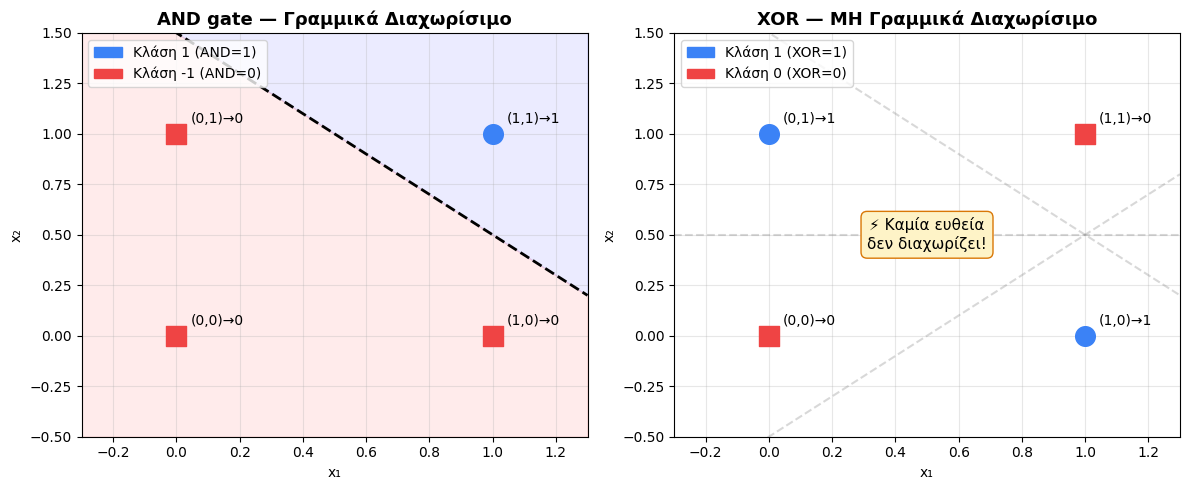

Αριστερά: ευθεία γραμμή χωρίζει τέλεια το AND.
Δεξιά: καμία ευθεία δεν χωρίζει το XOR → χρειαζόμαστε MLP.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- AND gate (γραμμικά διαχωρίσιμο) ---
ax = axes[0]
ax.set_title('AND gate — Γραμμικά Διαχωρίσιμο', fontsize=13, fontweight='bold')
points_and = [((0,0),-1), ((0,1),-1), ((1,0),-1), ((1,1),1)]
for (x, y), label in points_and:
    color = '#3b82f6' if label == 1 else '#ef4444'
    marker = 'o' if label == 1 else 's'
    ax.scatter(x, y, c=color, marker=marker, s=200, zorder=5)
    ax.annotate(f'({x},{y})→{1 if label==1 else 0}', (x, y),
                textcoords='offset points', xytext=(10, 8), fontsize=10)

# Γραμμή διαχωρισμού
x_line = np.linspace(-0.3, 1.3, 100)
y_line = 1.5 - x_line  # w1*x + w2*y = 1.5
ax.plot(x_line, y_line, 'k--', linewidth=2, label='Γραμμή διαχωρισμού')
ax.fill_between(x_line, y_line, 1.5, alpha=0.08, color='blue')
ax.fill_between(x_line, -0.5, y_line, alpha=0.08, color='red')
ax.set_xlim(-0.3, 1.3); ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.legend()
ax.grid(True, alpha=0.3)
patch_pos = mpatches.Patch(color='#3b82f6', label='Κλάση 1 (AND=1)')
patch_neg = mpatches.Patch(color='#ef4444', label='Κλάση -1 (AND=0)')
ax.legend(handles=[patch_pos, patch_neg], loc='upper left')

# --- XOR (μη γραμμικά διαχωρίσιμο) ---
ax = axes[1]
ax.set_title('XOR — ΜΗ Γραμμικά Διαχωρίσιμο', fontsize=13, fontweight='bold')
points_xor = [((0,0),0), ((0,1),1), ((1,0),1), ((1,1),0)]
for (x, y), label in points_xor:
    color = '#3b82f6' if label == 1 else '#ef4444'
    marker = 'o' if label == 1 else 's'
    ax.scatter(x, y, c=color, marker=marker, s=200, zorder=5)
    ax.annotate(f'({x},{y})→{label}', (x, y),
                textcoords='offset points', xytext=(10, 8), fontsize=10)

# Δοκιμή γραμμών — καμία δεν λειτουργεί
for slope, intercept, alpha in [(1, -0.5, 0.3), (0, 0.5, 0.3), (-1, 1.5, 0.3)]:
    y_try = slope * x_line + intercept
    ax.plot(x_line, y_try, 'gray', linewidth=1.5, alpha=alpha, linestyle='--')

ax.text(0.5, 0.5, '⚡ Καμία ευθεία\nδεν διαχωρίζει!',
        ha='center', va='center', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fef3c7', edgecolor='#d97706'))
ax.set_xlim(-0.3, 1.3); ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.grid(True, alpha=0.3)
patch_pos = mpatches.Patch(color='#3b82f6', label='Κλάση 1 (XOR=1)')
patch_neg = mpatches.Patch(color='#ef4444', label='Κλάση 0 (XOR=0)')
ax.legend(handles=[patch_pos, patch_neg], loc='upper left')

plt.tight_layout()
plt.savefig('../img/lec7/xor_linearity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Αριστερά: ευθεία γραμμή χωρίζει τέλεια το AND.')
print('Δεξιά: καμία ευθεία δεν χωρίζει το XOR → χρειαζόμαστε MLP.')

## 1.3 Εκπαίδευση Perceptron — Ο Αλγόριθμος Διόρθωσης Σφάλματος

Η κανόνας ενημέρωσης βαρών:

$$w_i \leftarrow w_i + \eta \cdot (t - \hat{y}) \cdot x_i$$

- Αν η πρόβλεψη είναι **σωστή** ($t = \hat{y}$): τα βάρη **δεν αλλάζουν**
- Αν η πρόβλεψη είναι **λάθος**: τα βάρη κινούνται προς τη σωστή κατεύθυνση

In [6]:
def train_perceptron(X, y, learning_rate=0.1, max_epochs=20):
    """Εκπαίδευση perceptron με αλγόριθμο διόρθωσης σφάλματος."""
    n_features = X.shape[1]
    w = np.zeros(n_features)  # αρχικοποίηση βαρών στο 0
    b = 0.0
    history = []

    for epoch in range(max_epochs):
        errors = 0
        for xi, ti in zip(X, y):
            z = np.dot(w, xi) + b
            y_hat = 1 if z > 0 else -1
            if y_hat != ti:  # λάθος → διόρθωση
                w += learning_rate * (ti - y_hat) * xi
                b += learning_rate * (ti - y_hat)
                errors += 1
        history.append(errors)
        if errors == 0:
            print(f'  Σύγκλιση στην εποχή {epoch + 1}!')
            break

    return w, b, history

# Δεδομένα AND
X_and = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_and = np.array([-1, -1, -1, 1])

print('Εκπαίδευση Perceptron στο AND gate:')
w_final, b_final, history = train_perceptron(X_and, y_and)
print(f'  Τελικά βάρη: w = {w_final}, b = {b_final:.2f}')

print('\nΈλεγχος:')
for xi, ti in zip(X_and, y_and):
    z = np.dot(w_final, xi) + b_final
    y_hat = 1 if z > 0 else -1
    print(f'  x={xi}, z={z:.2f}, ŷ={y_hat}, t={ti}  {"✓" if y_hat == ti else "✗"}')

Εκπαίδευση Perceptron στο AND gate:
  Σύγκλιση στην εποχή 6!
  Τελικά βάρη: w = [0.4 0.2], b = -0.40

Έλεγχος:
  x=[0. 0.], z=-0.40, ŷ=-1, t=-1  ✓
  x=[0. 1.], z=-0.20, ŷ=-1, t=-1  ✓
  x=[1. 0.], z=0.00, ŷ=-1, t=-1  ✓
  x=[1. 1.], z=0.20, ŷ=1, t=1  ✓


## 1.4 Συναρτήσεις Ενεργοποίησης

Κάθε νευρώνας εφαρμόζει $\hat{y} = f(z)$. Εδώ ορίζουμε τις κύριες συναρτήσεις, τις απεικονίζουμε γραφικά και δοκιμάζουμε τι επιστρέφει η καθεμία για δοσμένη είσοδο $z$.

### Ορισμός συναρτήσεων

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def step(z):
    """Βηματική — δεν χρησιμοποιείται (παράγωγος = 0)"""
    return np.where(z > 0, 1.0, 0.0)

def sigmoid(z):
    """Sigmoid — έξοδος binary, εύρος (0,1)"""
    return 1 / (1 + np.exp(-z))

def tanh(z):
    """Tanh — μηδενοκεντρική, εύρος (-1,1)"""
    return np.tanh(z)

def relu(z):
    """ReLU — default για κρυφά επίπεδα"""
    return np.maximum(0, z)

def leaky_relu(z, alpha=0.01):
    """Leaky ReLU — διορθώνει νεκρούς νευρώνες"""
    return np.where(z > 0, z, alpha * z)

def softmax(z_vector):
    """Softmax — για διάνυσμα, άθροισμα=1 (multi-class)"""
    e = np.exp(z_vector - np.max(z_vector))  # numerical stability
    return e / e.sum()

print('Συναρτήσεις ενεργοποίησης ορίστηκαν.')
print('Διαθέσιμες: step, sigmoid, tanh, relu, leaky_relu, softmax')

### Γραφική Παράσταση

Το παρακάτω διάγραμμα δείχνει πώς κάθε συνάρτηση μετασχηματίζει το $z$ — παρατηρήστε **πού είναι επίπεδη** η καμπύλη (vanishing gradient) και **πού είναι ενεργή**.

In [ ]:
z = np.linspace(-4, 4, 300)

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
fig.suptitle('Συναρτήσεις Ενεργοποίησης — f(z)', fontsize=14, fontweight='bold')

configs = [
    ('Step',       step(z),        '#dc2626', (-0.2, 1.2), '~~δεν χρησιμοποιείται~~\nf\'(z)=0 παντού'),
    ('Sigmoid',    sigmoid(z),     '#d97706', (-0.1, 1.1), 'εύρος (0,1)\nvanishing gradient στα άκρα'),
    ('Tanh',       tanh(z),        '#3b82f6', (-1.2, 1.2), 'εύρος (-1,1)\nμηδενοκεντρική'),
    ('ReLU',       relu(z),        '#16a34a', (-0.5, 4.2), 'εύρος [0,∞)\nνεκροί νευρώνες για z<0'),
    ('Leaky ReLU', leaky_relu(z),  '#7c3aed', (-0.5, 4.2), 'εύρος (-∞,∞)\nδιορθώνει νεκρούς νευρώνες'),
]

for ax, (name, vals, color, ylim, note) in zip(axes, configs):
    ax.plot(z, vals, color=color, linewidth=2.5)
    ax.axhline(0, color='#94a3b8', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='#94a3b8', linewidth=0.8, linestyle='--')
    # shade dead zone for ReLU / Leaky
    if name in ('ReLU', 'Leaky ReLU'):
        ax.axvspan(-4, 0, alpha=0.07, color='#dc2626')
        ax.text(-3.5, 3.5, 'νεκρή\nζώνη', fontsize=8, color='#dc2626', va='top')
    ax.set_title(name, fontweight='bold', fontsize=12, color=color)
    ax.set_xlabel('z')
    ax.set_ylabel('f(z)')
    ax.set_ylim(ylim)
    ax.set_xlim(-4, 4)
    ax.text(0.05, 0.05, note, transform=ax.transAxes,
            fontsize=8, color='#374151', va='bottom',
            bbox=dict(facecolor='white', edgecolor=color, boxstyle='round,pad=0.3', alpha=0.8))
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Διαδραστικό Παράδειγμα — Δώσε Τιμή $z$

Άλλαξε την τιμή του `z_input` και δες τι επιστρέφει κάθε συνάρτηση.

> Δοκίμασε: `z = -0.12` (από το παράδειγμα Perceptron), `z = 5`, `z = -5`, `z = 0`

In [ ]:
# ── Άλλαξε αυτή την τιμή ──
z_input = -0.12
# ───────────────────────────

print(f'Είσοδος:  z = {z_input}')
print('=' * 45)

results = [
    ('Step',       step(z_input),               'έξοδος 0 ή 1 — καμία απόχρωση'),
    ('Sigmoid',    sigmoid(z_input),             'P ∈ (0,1) — ερμηνεύεται ως πιθανότητα'),
    ('Tanh',       tanh(z_input),                'εύρος (-1,1) — μηδενοκεντρική'),
    ('ReLU',       relu(z_input),                'max(0,z) — 0 αν z<0'),
    ('Leaky ReLU', leaky_relu(z_input),          'μικρό σήμα ακόμα και για z<0'),
]

for name, val, note in results:
    print(f'{name:<14} → {val:+.5f}   ({note})')

# Softmax χρειάζεται διάνυσμα
print()
z_vec = np.array([z_input, z_input - 1.0, z_input + 0.5])
sm = softmax(z_vec)
print(f'Softmax({z_vec}) → {sm.round(3)}')
print(f'  Άθροισμα: {sm.sum():.6f}  (πάντα = 1.0)')

# Οπτικοποίηση αποτελεσμάτων
fig, ax = plt.subplots(figsize=(9, 3))
names  = [r[0] for r in results]
values = [float(r[1]) for r in results]
colors = ['#dc2626' if v == 0 and z_input < 0 else '#16a34a' if v > 0 else '#3b82f6'
          for v in values]
bars = ax.barh(names, values, color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='#94a3b8', linewidth=1)
for bar, val in zip(bars, values):
    ax.text(val + (0.02 if val >= 0 else -0.02),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.4f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=10)
ax.set_title(f'Έξοδος κάθε συνάρτησης για z = {z_input}',
             fontweight='bold', fontsize=12)
ax.set_xlabel('f(z)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---

# Μέρος 2: MLP με sklearn — Churn Prediction

## 2.1 Φόρτωση και Προεπεξεργασία Δεδομένων

In [7]:
# Φόρτωση Telco Churn dataset
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

# Προεπεξεργασία
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop(columns=['customerID'], inplace=True)

# Κωδικοποίηση κατηγορικών μεταβλητών
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print(f'Dataset: {df.shape[0]} γραμμές, {df.shape[1]} στήλες')
print(f'Churn distribution:')
print(df['Churn'].value_counts())

Dataset: 7032 γραμμές, 20 στήλες
Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


/tmp/ipykernel_69690/1380547528.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


### Διαχωρισμός και Κανονικοποίηση Δεδομένων

Δύο κρίσιμα βήματα πριν εκπαιδεύσουμε το νευρωνικό δίκτυο:

**Train/Test split** — χωρίζουμε 80%/20% (stratified: διατηρείται η αναλογία Churn).  
Το test set δεν αγγίζεται μέχρι την τελική αξιολόγηση.

**StandardScaler** — κανονικοποίηση σε μέση τιμή=0, τυπική απόκλιση=1:

$$x' = \frac{x - \mu}{\sigma}$$

> Είναι **κρίσιμο για τα νευρωνικά δίκτυα**: features με μεγάλες τιμές (π.χ. `TotalCharges`)  
> κυριαρχούν στον υπολογισμό των βαρών και καθυστερούν ή αποτυγχάνουν την εκπαίδευση.

Σημείωση: το scaler εκπαιδεύεται **μόνο** στο train set — δεν «βλέπει» το test set.

In [8]:
X = df.drop(columns=['Churn']).values
y = df['Churn'].values

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Κανονικοποίηση — κρίσιμο για τα NN!
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'\n⚠️  Σημείωση: Η κανονικοποίηση (StandardScaler) είναι κρίσιμη για τα')
print(f'    νευρωνικά δίκτυα. Χωρίς αυτή, χαρακτηριστικά με μεγάλες τιμές')
print(f'    (π.χ. TotalCharges) κυριαρχούν και η εκπαίδευση αστοχεί.')

Train: (5625, 19), Test: (1407, 19)

⚠️  Σημείωση: Η κανονικοποίηση (StandardScaler) είναι κρίσιμη για τα
    νευρωνικά δίκτυα. Χωρίς αυτή, χαρακτηριστικά με μεγάλες τιμές
    (π.χ. TotalCharges) κυριαρχούν και η εκπαίδευση αστοχεί.


## 2.2 Ορισμός και Εκπαίδευση MLP

Χρησιμοποιούμε `sklearn.neural_network.MLPClassifier` — ισοδύναμη αρχιτεκτονική με Keras Sequential, χωρίς εξωτερικές εξαρτήσεις:

```
Input (19 features)
    ↓
Dense(64) → ReLU
    ↓
Dense(32) → ReLU
    ↓
Dense(1)  → Sigmoid
    ↓
P(Churn) ∈ [0, 1]
```

> **Σημείωση:** Το sklearn MLPClassifier υποστηρίζει Early Stopping (`early_stopping=True`)  
> και L2 regularization (`alpha`) — ισοδύναμα με το Dropout του Keras.


In [9]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # 2 κρυφά επίπεδα: 64 και 32 νευρώνες
    activation='relu',             # ReLU ενεργοποίηση
    solver='adam',                 # Adam optimizer
    alpha=0.001,                   # L2 regularization (αντί Dropout)
    max_iter=200,                  # μέγιστοι epochs
    early_stopping=True,           # σταματάμε αν δεν βελτιώνεται
    validation_fraction=0.2,       # 20% του train για validation
    n_iter_no_change=10,           # patience = 10 epochs
    random_state=42,
    verbose=False
)

# Σύνοψη αρχιτεκτονικής
print('MLP Αρχιτεκτονική:')
print(f'  Είσοδος:        {X_train.shape[1]} features')
print(f'  Κρυφό επίπεδο 1: 64 νευρώνες, ReLU')
print(f'  Κρυφό επίπεδο 2: 32 νευρώνες, ReLU')
print(f'  Έξοδος:          1 νευρώνας, Sigmoid (P(Churn))')
print(f'  Optimizer:       Adam')
print(f'  Regularization:  L2 (alpha={mlp.alpha})')
print(f'  Early Stopping:  patience={mlp.n_iter_no_change} epochs')

# Υπολογισμός παραμέτρων χειροκίνητα
n_features = X_train.shape[1]
p1 = n_features * 64 + 64   # weights + biases για layer 1
p2 = 64 * 32 + 32           # weights + biases για layer 2
p3 = 32 * 1 + 1             # weights + biases για output
print(f'\nΣύνολο παραμέτρων: {p1+p2+p3:,}')

MLP Αρχιτεκτονική:
  Είσοδος:        19 features
  Κρυφό επίπεδο 1: 64 νευρώνες, ReLU
  Κρυφό επίπεδο 2: 32 νευρώνες, ReLU
  Έξοδος:          1 νευρώνας, Sigmoid (P(Churn))
  Optimizer:       Adam
  Regularization:  L2 (alpha=0.001)
  Early Stopping:  patience=10 epochs

Σύνολο παραμέτρων: 3,393


### Εκπαίδευση — Τι Συμβαίνει Εσωτερικά;

Ο `MLPClassifier.fit()` εκτελεί **gradient descent** με τον αλγόριθμο Adam:

1. **Forward pass**: τα δεδομένα περνούν μπροστά → υπολογίζεται η πρόβλεψη
2. **Loss**: μετράται η διαφορά πρόβλεψης–αλήθειας (binary cross-entropy)
3. **Backward pass**: το σφάλμα «ταξιδεύει» προς τα πίσω (backpropagation)
4. **Update**: τα βάρη ενημερώνονται για να μειωθεί το σφάλμα

Με `early_stopping=True`, ο αλγόριθμος κρατά το 20% του train ως validation  
και σταματά αν δεν βελτιώνεται για `n_iter_no_change=10` epochs.

In [10]:
# Εκπαίδευση — Early Stopping ενεργοποιείται αυτόματα
mlp.fit(X_train, y_train)

print(f'Epochs που εκτελέστηκαν: {mlp.n_iter_}')
print(f'Τελική training loss:     {mlp.loss_:.4f}')
print(f'Καλύτερο validation score: {mlp.best_validation_score_:.4f}')

# Αξιολόγηση στο test set
y_pred_prob = mlp.predict_proba(X_test)[:, 1]
y_pred = (y_pred_prob > 0.5).astype(int)

print('\n=== Αποτελέσματα στο Test Set ===')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Epochs που εκτελέστηκαν: 43
Τελική training loss:     0.3538
Καλύτερο validation score: 0.7911

=== Αποτελέσματα στο Test Set ===
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.86      1033
       Churn       0.64      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



## 2.3 Οπτικοποίηση Εκπαίδευσης — Training Loss & Validation Score

Το `MLPClassifier` αποθηκεύει το `loss_curve_` (training loss ανά epoch) και  
το `validation_scores_` (validation accuracy ανά epoch, με `early_stopping=True`).  
Παρατηρήστε πότε σταματά η εκπαίδευση λόγω Early Stopping.

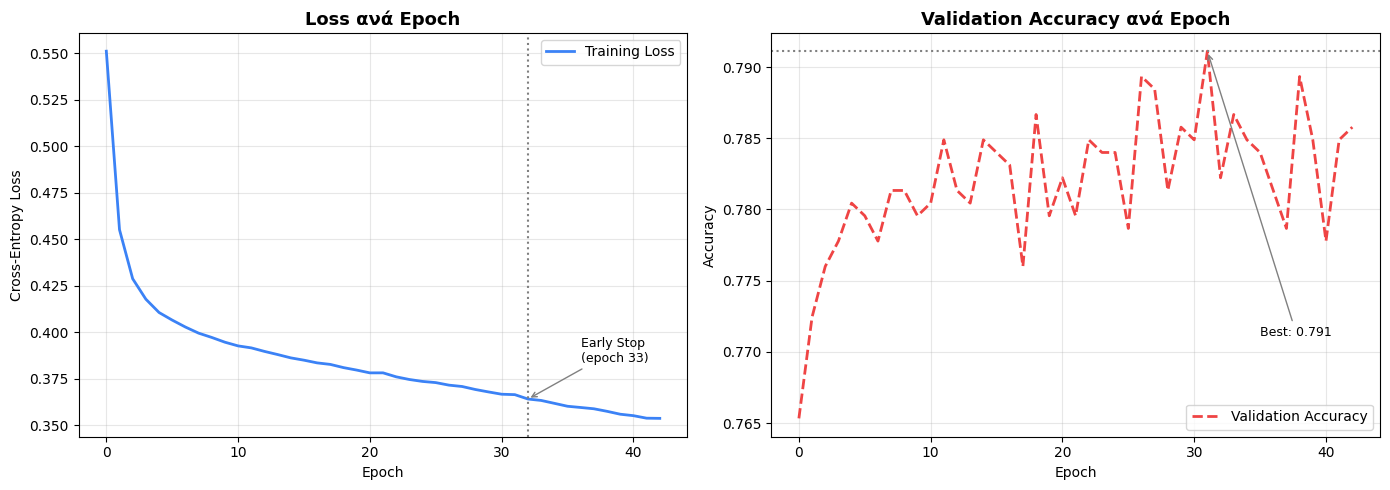


Συνολικοί epochs: 43
Η εκπαίδευση σταμάτησε 10 epochs μετά το βέλτιστο


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training Loss
ax = axes[0]
ax.plot(mlp.loss_curve_, color='#3b82f6', linewidth=2, label='Training Loss')
best_epoch = len(mlp.loss_curve_) - mlp.n_iter_no_change - 1
best_epoch = max(0, best_epoch)
ax.axvline(best_epoch, color='gray', linestyle=':', linewidth=1.5)
ax.annotate(
    f'Early Stop\n(epoch {best_epoch+1})',
    xy=(best_epoch, mlp.loss_curve_[best_epoch]),
    xytext=(best_epoch + max(2, len(mlp.loss_curve_)//10),
            mlp.loss_curve_[best_epoch] + 0.02),
    fontsize=9, arrowprops=dict(arrowstyle='->', color='gray')
)
ax.set_title('Loss ανά Epoch', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Validation Score (accuracy)
ax = axes[1]
ax.plot(mlp.validation_scores_, color='#ef4444', linewidth=2,
        linestyle='--', label='Validation Accuracy')
ax.axhline(mlp.best_validation_score_, color='gray', linestyle=':', linewidth=1.5)
ax.annotate(
    f'Best: {mlp.best_validation_score_:.3f}',
    xy=(np.argmax(mlp.validation_scores_), mlp.best_validation_score_),
    xytext=(np.argmax(mlp.validation_scores_) + max(2, len(mlp.validation_scores_)//10),
            mlp.best_validation_score_ - 0.02),
    fontsize=9, arrowprops=dict(arrowstyle='->', color='gray')
)
ax.set_title('Validation Accuracy ανά Epoch', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nΣυνολικοί epochs: {mlp.n_iter_}')
print(f'Η εκπαίδευση σταμάτησε {mlp.n_iter_no_change} epochs μετά το βέλτιστο')

### Confusion Matrix — Ανάλυση Σφαλμάτων

Η **confusion matrix** δείχνει τέσσερις κατηγορίες προβλέψεων:

| | Πρόβλεψη: No Churn | Πρόβλεψη: Churn |
|---|---|---|
| **Πραγματικό: No Churn** | True Negative (σωστά) | False Positive (λάθος alarm) |
| **Πραγματικό: Churn** | False Negative (χάσαμε!) | True Positive (σωστά) |

> Στο πρόβλημα churn, τα **False Negatives** είναι πιο ακριβά — χάνουμε πελάτες  
> που δεν εντοπίσαμε. Για αυτό συχνά κατεβάζουμε το threshold κάτω από 0.5.

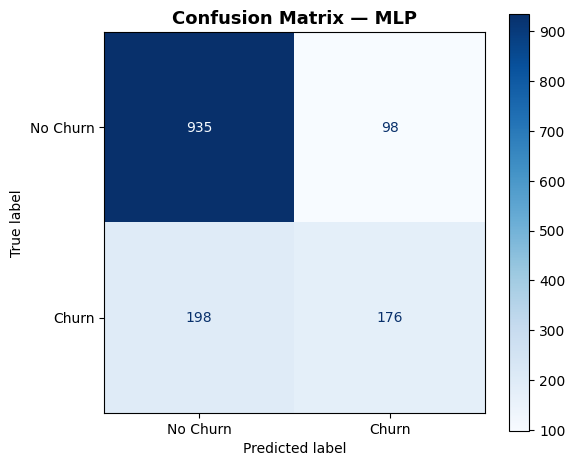

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Churn', 'Churn'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — MLP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

# Μέρος 3: Explainable AI — SHAP

## 3.1 Γιατί χρειαζόμαστε εξηγησιμότητα;

Το MLP μας έδωσε μια πρόβλεψη — αλλά **γιατί** πρόβλεψε ότι κάποιος πελάτης θα φύγει;  
Το SHAP απαντά: **κάθε χαρακτηριστικό συνέβαλε κατά +X% ή -X%** στην τελική πρόβλεψη.

> **Additivity:** $\hat{y} = \phi_0 + \phi_1 + \phi_2 + \ldots + \phi_n$  
> Το άθροισμα κλείνει **ακριβώς** — πάντα.

In [16]:
# Εγκατάσταση αν χρειαστεί
# !pip install shap -q

import shap

# Χρησιμοποιούμε Random Forest για SHAP (πιο γρήγορο από deep NN)
# — οι αρχές XAI ισχύουν ανεξάρτητα από τον αλγόριθμο
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
print(f'Random Forest accuracy: {rf.score(X_test, y_test):.3f}')

Random Forest accuracy: 0.783


### Υπολογισμός SHAP Values με TreeExplainer

Το `shap.TreeExplainer` είναι βελτιστοποιημένο για **δενδρικά μοντέλα** (Random Forest, XGBoost)  
και υπολογίζει τις ακριβείς SHAP τιμές σε polynomial χρόνο (αντί exponential).

Το αποτέλεσμα `shap_values_3d` έχει σχήμα `(n_δείγματα, n_features, 2)`:  
- `[:, :, 0]` → SHAP values για κλάση 0 (No Churn)  
- `[:, :, 1]` → SHAP values για κλάση 1 (Churn) ← αυτό μας ενδιαφέρει

Το `base_val = expected_value[1]` είναι η **μέση πρόβλεψη** P(Churn) του μοντέλου στα δεδομένα εκπαίδευσης.

In [17]:
feature_names = df.drop(columns=['Churn']).columns.tolist()

# SHAP TreeExplainer — βελτιστοποιημένος για tree-based μοντέλα
explainer = shap.TreeExplainer(rf)
shap_values_3d = explainer.shap_values(X_test)  # shape: (n_samples, n_features, 2)

# SHAP 0.44+: επιστρέφει 3D array — [:, :, 1] = τιμές για κλάση 1 (Churn)
sv = shap_values_3d[:, :, 1]      # (n_test, n_features)
base_val = explainer.expected_value[1]  # μέση πρόβλεψη για κλάση 1

print(f'SHAP values shape (class 1): {sv.shape}')
print(f'Base value (μέση πρόβλεψη): {base_val:.3f}')

SHAP values shape (class 1): (1407, 19)
Base value (μέση πρόβλεψη): 0.265


## 3.2 Global Explanation — Ποια Features Έχουν Γενικά Σημασία;

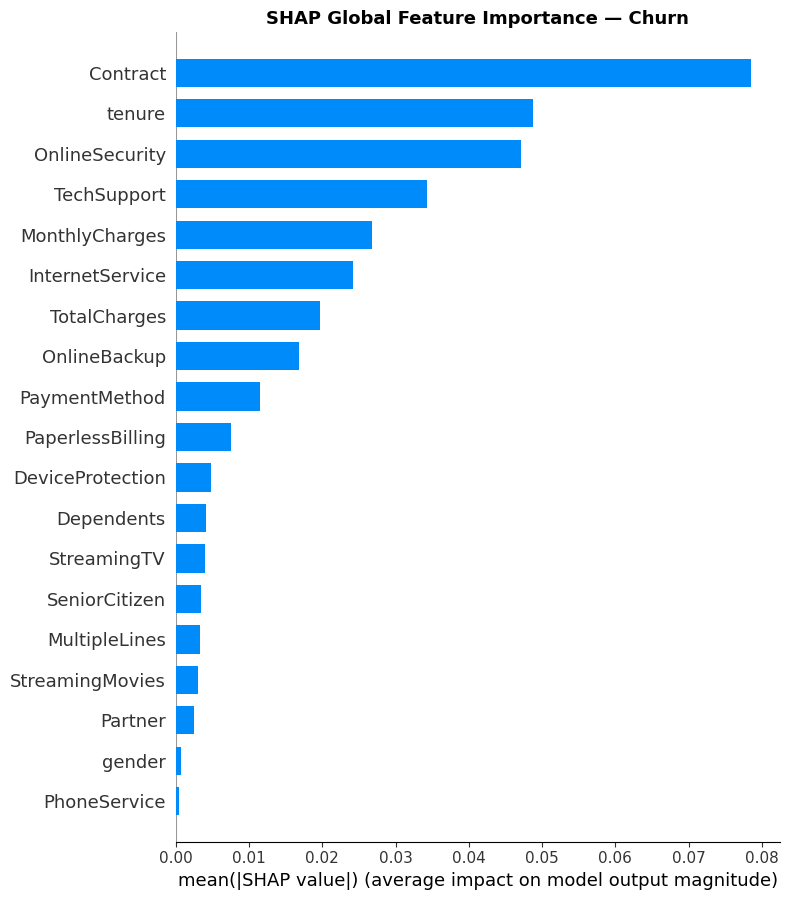

In [18]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv,
    X_test,
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.title('SHAP Global Feature Importance — Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Beeswarm Plot — Κατεύθυνση και Κατανομή

Το bar plot έδειξε το **μέγεθος** της επίδρασης. Το **beeswarm** προσθέτει δύο πληροφορίες:

| Διάσταση | Ερμηνεία |
|---|---|
| Θέση στον άξονα x | Κατεύθυνση: δεξιά = αυξάνει P(Churn), αριστερά = μειώνει |
| Χρώμα σημείου | Τιμή feature: κόκκινο = υψηλή, μπλε = χαμηλή |

Παράδειγμα: αν το `tenure` εμφανίζεται **μπλε στα αριστερά**, σημαίνει ότι  
οι *νέοι* πελάτες (χαμηλό tenure) έχουν αυξημένη πιθανότητα churn.

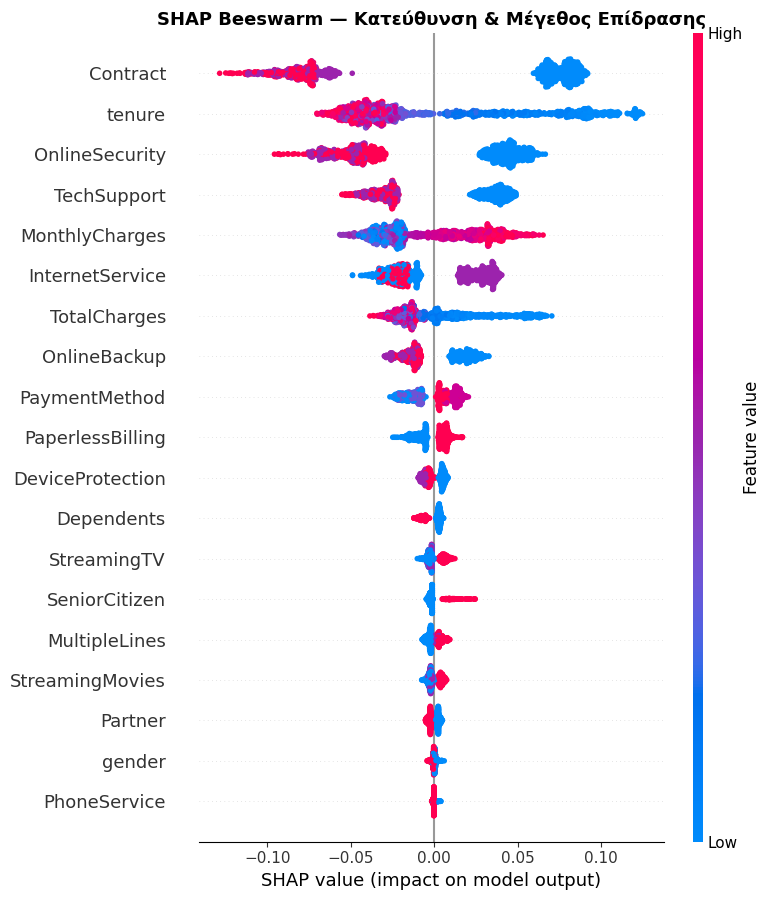

Κόκκινο = υψηλή τιμή feature, Μπλε = χαμηλή τιμή feature
Δεξιά του 0 = αυξάνει P(Churn), Αριστερά = μειώνει P(Churn)


In [19]:
# Beeswarm plot — δείχνει κατεύθυνση (θετική/αρνητική) και κατανομή
plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv,
    X_test,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Beeswarm — Κατεύθυνση & Μέγεθος Επίδρασης', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Κόκκινο = υψηλή τιμή feature, Μπλε = χαμηλή τιμή feature')
print('Δεξιά του 0 = αυξάνει P(Churn), Αριστερά = μειώνει P(Churn)')

## 3.3 Local Explanation — Γιατί ΑΥΤΌς ο Πελάτης Φεύγει;

Επαληθεύουμε την **additive ιδιότητα**: base value + SHAP values = τελική πρόβλεψη

In [20]:
# Επιλέγουμε έναν πελάτη που προβλέφθηκε ως Churn
churn_indices = np.where(y_pred == 1)[0]
idx = churn_indices[0]

shap_sum = sv[idx].sum()
final_pred = base_val + shap_sum

print(f'=== Πελάτης #{idx} ===')
print(f'Βάση (μέση πρόβλεψη):  {base_val:.4f}')
print(f'Άθροισμα SHAP values:   {shap_sum:+.4f}')
print(f'Τελική πρόβλεψη:        {final_pred:.4f}')
print(f'Πρόβλεψη μοντέλου:      {rf.predict_proba(X_test[[idx]])[0,1]:.4f}')
print(f'\n✓ base + SHAP = {base_val:.4f} + {shap_sum:+.4f} = {final_pred:.4f}')
print(f'  Αυτό είναι η Additive ιδιότητα του SHAP!')

# Top 5 features που επηρεάζουν αυτόν τον πελάτη
print(f'\nTop 5 features για τον πελάτη #{idx}:')
shap_df = pd.DataFrame({
    'Feature': feature_names,
    'Τιμή': X_test[idx],
    'SHAP': sv[idx]
}).sort_values('SHAP', key=abs, ascending=False).head(5)
print(shap_df.to_string(index=False))

=== Πελάτης #1 ===
Βάση (μέση πρόβλεψη):  0.2650
Άθροισμα SHAP values:   +0.3449
Τελική πρόβλεψη:        0.6099
Πρόβλεψη μοντέλου:      0.6099

✓ base + SHAP = 0.2650 + +0.3449 = 0.6099
  Αυτό είναι η Additive ιδιότητα του SHAP!

Top 5 features για τον πελάτη #1:
        Feature      Τιμή     SHAP
       Contract -0.830880 0.084997
         tenure -1.041649 0.081898
 OnlineSecurity -0.916406 0.062420
    TechSupport -0.930592 0.047609
InternetService  0.175326 0.035755


### Waterfall Plot — Εξήγηση μιας Πρόβλεψης Βήμα-Βήμα

Το **waterfall plot** είναι ο πιο διαισθητικός τρόπος εξήγησης μιας μεμονωμένης πρόβλεψης:

- Ξεκινάμε από τη **βάση** `E[f(X)]` (μέση πρόβλεψη όλων των δεδομένων)
- Κάθε feature προσθέτει ή αφαιρεί ένα ποσό (SHAP value)
- Καταλήγουμε στην **τελική πρόβλεψη** `f(x)` για αυτόν τον συγκεκριμένο πελάτη

Κόκκινες μπάρες = αύξηση P(Churn), Μπλε = μείωση.

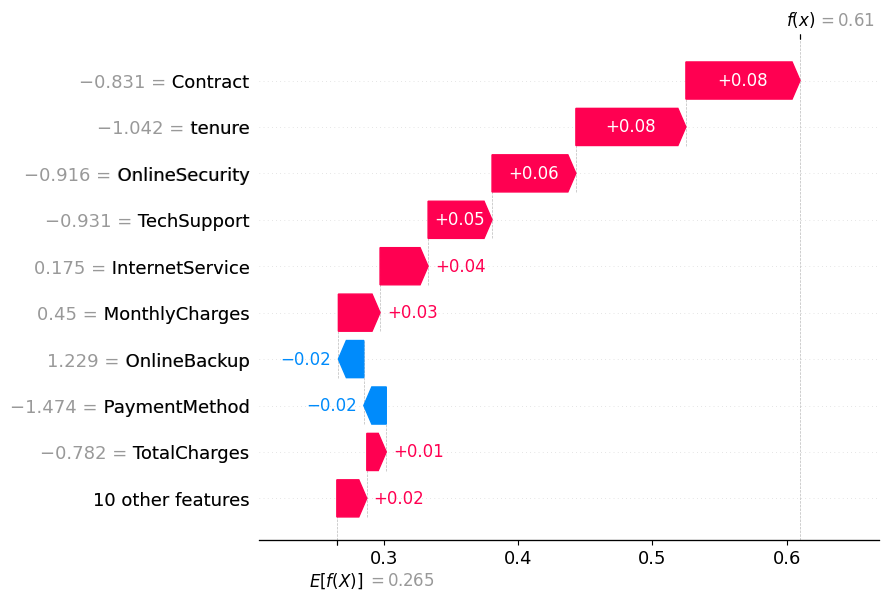

In [21]:
# Waterfall plot — ο πιο διαισθητικός τρόπος εξήγησης
shap.waterfall_plot(
    shap.Explanation(
        values=sv[idx],
        base_values=base_val,
        data=X_test[idx],
        feature_names=feature_names
    )
)

---

# Μέρος 4: LLMs & Prompt Engineering

## 4.1 Η Παράμετρος Temperature

Η **θερμοκρασία (temperature)** ελέγχει πόσο «τυχαία» ή «δημιουργική» είναι η απόκριση ενός LLM:

| Temperature | Συμπεριφορά | Χρήση |
|---|---|---|
| **0.0** | Ντετερμινιστικό — πάντα την πιο πιθανή λέξη | Κώδικας, ανάλυση δεδομένων, νομικά |
| **0.5** | Ισορροπία ακρίβειας και ποικιλίας | Γενικές ερωτήσεις |
| **≥ 0.8** | Δημιουργικό — επιλέγει λιγότερο πιθανές λέξεις | Brainstorming, marketing, ιδέες |

Ας δούμε τι σημαίνει αυτό **μαθηματικά** με ένα απλό παράδειγμα.


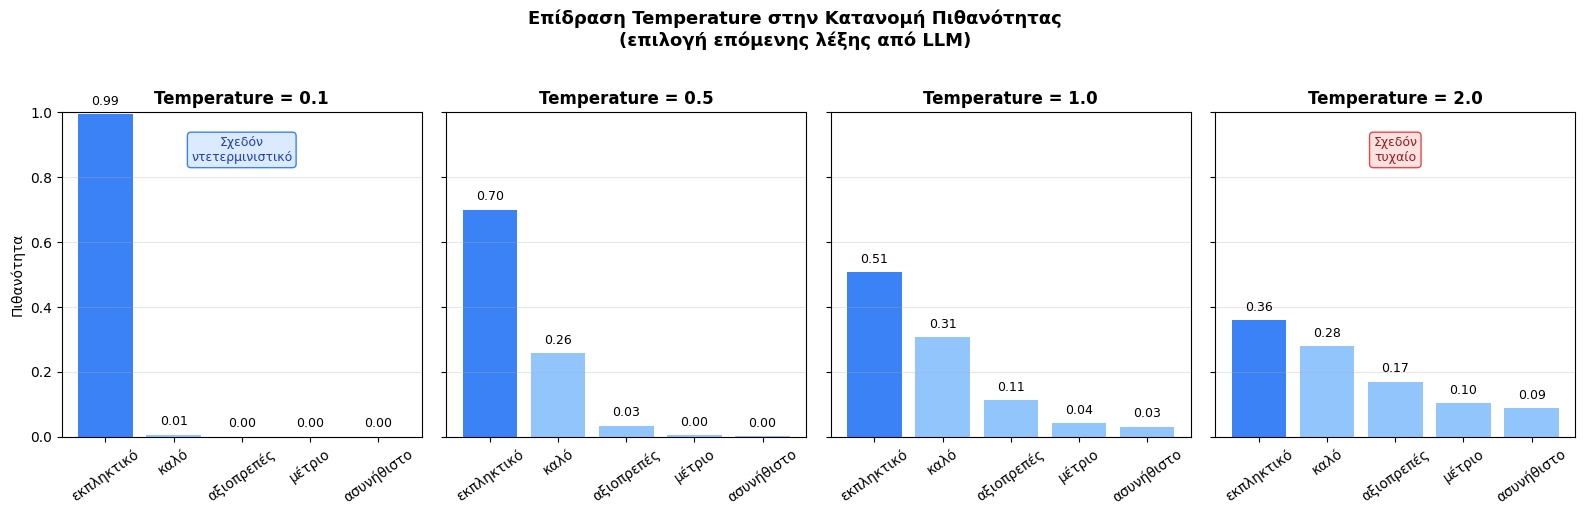

Παρατήρηση:
  T=0.1: Η λέξη "εκπληκτικό" έχει σχεδόν 100% — κάθε φορά το ίδιο
  T=2.0: Ακόμα και η λέξη "ασυνήθιστο" έχει αξιόλογη πιθανότητα
  → Υψηλό temperature = περισσότερη δημιουργικότητα, αλλά & περισσότερα hallucinations


In [22]:
def softmax_with_temperature(logits, temperature):
    """Softmax με temperature scaling.
    Χαμηλό T → πιο sharp κατανομή (ντετερμινιστικό)
    Υψηλό T  → πιο flat κατανομή (τυχαίο)
    """
    scaled = np.array(logits) / temperature
    exp_scaled = np.exp(scaled - np.max(scaled))  # numerical stability
    return exp_scaled / exp_scaled.sum()

# Φανταστείτε ότι το μοντέλο πρέπει να επιλέξει την επόμενη λέξη
# Logits (raw scores) για 5 πιθανές λέξεις
words = ['εκπληκτικό', 'καλό', 'αξιοπρεπές', 'μέτριο', 'ασυνήθιστο']
logits = [3.0, 2.5, 1.5, 0.5, 0.2]

temperatures = [0.1, 0.5, 1.0, 2.0]
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)

for ax, T in zip(axes, temperatures):
    probs = softmax_with_temperature(logits, T)
    colors = ['#3b82f6' if p == probs.max() else '#93c5fd' for p in probs]
    bars = ax.bar(words, probs, color=colors)
    ax.set_title(f'Temperature = {T}', fontweight='bold', fontsize=12)
    ax.set_ylabel('Πιθανότητα' if T == 0.1 else '')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=35)
    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{p:.2f}', ha='center', va='bottom', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    # Annotation
    if T == 0.1:
        ax.text(0.5, 0.85, 'Σχεδόν\nντετερμινιστικό', transform=ax.transAxes,
                ha='center', fontsize=9, color='#1e40af',
                bbox=dict(facecolor='#dbeafe', edgecolor='#3b82f6', boxstyle='round'))
    elif T == 2.0:
        ax.text(0.5, 0.85, 'Σχεδόν\nτυχαίο', transform=ax.transAxes,
                ha='center', fontsize=9, color='#991b1b',
                bbox=dict(facecolor='#fee2e2', edgecolor='#ef4444', boxstyle='round'))

plt.suptitle('Επίδραση Temperature στην Κατανομή Πιθανότητας\n(επιλογή επόμενης λέξης από LLM)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Παρατήρηση:')
print('  T=0.1: Η λέξη "εκπληκτικό" έχει σχεδόν 100% — κάθε φορά το ίδιο')
print('  T=2.0: Ακόμα και η λέξη "ασυνήθιστο" έχει αξιόλογη πιθανότητα')
print('  → Υψηλό temperature = περισσότερη δημιουργικότητα, αλλά & περισσότερα hallucinations')

## 4.2 Prompt Engineering — Σύγκριση Prompts

Χρησιμοποιούμε το **Google Gemini API** (δωρεάν tier με `gemini-2.0-flash`).

**Βήματα:**
1. Δημιουργήστε δωρεάν λογαριασμό στο [aistudio.google.com](https://aistudio.google.com)
2. Δημιουργήστε ένα API key (`Get API key`)
3. Ορίστε: `export GEMINI_API_KEY='AIza...'` (ή βάλτε το απευθείας στον κώδικα)

> Αν δεν έχετε key, ο κώδικας εκτελείται κανονικά και εμφανίζει demo αποτελέσματα.

In [25]:
import os

try:
    import google.generativeai as genai

    api_key = os.environ.get('GEMINI_API_KEY', '')
    if not api_key:
        raise ValueError('GEMINI_API_KEY not set')

    genai.configure(api_key=api_key)
    model = genai.GenerativeModel('gemini-2.0-flash')

    prompts = {
        'Κακό (vague)': 'Ανάλυσε τα δεδομένα churn.',
        'Καλό (specific)': (
            'Είσαι αναλυτής churn σε εταιρεία τηλεπικοινωνιών. '
            'Τα δεδομένα μου δείχνουν ότι το tenure και ο τύπος συμβολαίου '
            'είναι τα πιο σημαντικά features για πρόβλεψη churn. '
            'Δώσε μου 3 συγκεκριμένες στρατηγικές παρέμβασης για πελάτες '
            'με tenure < 6 μήνες και μηνιαία σύμβαση. '
            'Απάντησε σε 3 bullet points.'
        )
    }

    config = genai.types.GenerationConfig(temperature=0.3, max_output_tokens=300)

    for label, prompt_text in prompts.items():
        print(f'\n{"="*60}')
        print(f'Prompt: {label}')
        print(f'{"="*60}')
        response = model.generate_content(prompt_text, generation_config=config)
        print(response.text)

except ValueError:
    print('⚠️  GEMINI_API_KEY δεν βρέθηκε — εμφανίζεται demo αποτέλεσμα.')
    print()
    print('=' * 60)
    print('Prompt: Κακό (vague)')
    print('=' * 60)
    print('Για να αναλύσω τα δεδομένα churn χρειάζομαι περισσότερες')
    print('πληροφορίες. Τι είδους ανάλυση θέλετε; Ποιο dataset;')
    print()
    print('=' * 60)
    print('Prompt: Καλό (specific)')
    print('=' * 60)
    print('• Προσφέρετε discount 20% για upgrade σε ετήσιο πρόγραμμα')
    print('  τους πρώτους 3 μήνες — μειώνει την αβεβαιότητα νέου πελάτη.')
    print('• Ενεργοποιήστε proactive customer success call στον μήνα 2-3,')
    print('  πριν εμφανιστεί πρόβλημα.')
    print('• Gamification onboarding: μπόνους data/λεπτά αν ολοκληρώσουν')
    print('  το setup profile εντός 30 ημερών.')
    print()
    print('→ Παρατηρήστε: το specific prompt δίνει actionable απαντήσεις.')
except ImportError:
    print('Εγκαταστήστε: pip install google-generativeai')
except Exception as e:
    print(f'Σφάλμα: {e}')

⚠️  GEMINI_API_KEY δεν βρέθηκε — εμφανίζεται demo αποτέλεσμα.

Prompt: Κακό (vague)
Για να αναλύσω τα δεδομένα churn χρειάζομαι περισσότερες
πληροφορίες. Τι είδους ανάλυση θέλετε; Ποιο dataset;

Prompt: Καλό (specific)
• Προσφέρετε discount 20% για upgrade σε ετήσιο πρόγραμμα
  τους πρώτους 3 μήνες — μειώνει την αβεβαιότητα νέου πελάτη.
• Ενεργοποιήστε proactive customer success call στον μήνα 2-3,
  πριν εμφανιστεί πρόβλημα.
• Gamification onboarding: μπόνους data/λεπτά αν ολοκληρώσουν
  το setup profile εντός 30 ημερών.

→ Παρατηρήστε: το specific prompt δίνει actionable απαντήσεις.


/tmp/ipykernel_69690/1511387349.py:4: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


## 4.3 Επίδραση Temperature στις Απαντήσεις

Ίδιο prompt, `temperature=0.0` vs `temperature=1.5` — παρατηρήστε πώς αλλάζει η απόκριση.

> Υπενθύμιση: το Gemini υποστηρίζει temperature από 0.0 έως 2.0.

In [26]:
import os

try:
    import google.generativeai as genai

    api_key = os.environ.get('GEMINI_API_KEY', '')
    if not api_key:
        raise ValueError('no key')

    genai.configure(api_key=api_key)
    model = genai.GenerativeModel('gemini-2.0-flash')

    prompt_text = (
        'Δώσε μου 3 ιδέες για καμπάνια διατήρησης πελατών '
        'που απειλούνται με churn στον κλάδο τηλεπικοινωνιών.'
    )

    for temp in [0.0, 1.5]:
        print(f'\n{"="*60}')
        print(f'Temperature = {temp}')
        print(f'{"="*60}')
        config = genai.types.GenerationConfig(temperature=temp, max_output_tokens=250)
        response = model.generate_content(prompt_text, generation_config=config)
        print(response.text)

except ValueError:
    print('⚠️  GEMINI_API_KEY δεν βρέθηκε — εμφανίζεται demo αποτέλεσμα.')
    print()
    print('=' * 60)
    print('Temperature = 0.0  (ντετερμινιστικό)')
    print('=' * 60)
    print('1. Προσφορά έκπτωσης 15% για ανανέωση συμβολαίου.')
    print('2. Δωρεάν μήνας υπηρεσίας για πελάτες με tenure < 6 μήνες.')
    print('3. Προσωποποιημένο email με σύνοψη των οφελών του πλάνου τους.')
    print()
    print('=' * 60)
    print('Temperature = 1.5  (δημιουργικό)')
    print('=' * 60)
    print('1. "Loyalty passport": κάθε μήνα ξεκλειδώνουν exclusive perks')
    print('   (streaming sub, cloud storage) — gamification της παραμονής.')
    print('2. Community challenge: referral program με ομαδικές εκπτώσεις')
    print('   αν φέρουν 2 φίλους — social proof κατά του churn.')
    print('3. "Surprise & delight" καμπάνια: τυχαίο δώρο δεδομένων τον 5ο μήνα')
    print('   — σπάει το pattern της «αδιαφορίας» πριν τη διακοπή.')
    print()
    print('→ T=0.0: τυπικές, προβλέψιμες ιδέες')
    print('→ T=1.5: πιο πρωτότυπες, αλλά κινδυνεύουν για hallucination')
except ImportError:
    print('Εγκαταστήστε: pip install google-generativeai')
except Exception as e:
    print(f'Σφάλμα: {e}')

⚠️  GEMINI_API_KEY δεν βρέθηκε — εμφανίζεται demo αποτέλεσμα.

Temperature = 0.0  (ντετερμινιστικό)
1. Προσφορά έκπτωσης 15% για ανανέωση συμβολαίου.
2. Δωρεάν μήνας υπηρεσίας για πελάτες με tenure < 6 μήνες.
3. Προσωποποιημένο email με σύνοψη των οφελών του πλάνου τους.

Temperature = 1.5  (δημιουργικό)
1. "Loyalty passport": κάθε μήνα ξεκλειδώνουν exclusive perks
   (streaming sub, cloud storage) — gamification της παραμονής.
2. Community challenge: referral program με ομαδικές εκπτώσεις
   αν φέρουν 2 φίλους — social proof κατά του churn.
3. "Surprise & delight" καμπάνια: τυχαίο δώρο δεδομένων τον 5ο μήνα
   — σπάει το pattern της «αδιαφορίας» πριν τη διακοπή.

→ T=0.0: τυπικές, προβλέψιμες ιδέες
→ T=1.5: πιο πρωτότυπες, αλλά κινδυνεύουν για hallucination


---

# Σύνοψη

| Θέμα | Τι μάθαμε |
|---|---|
| **Perceptron** | Βιολογική αναλογία, αλγόριθμος διόρθωσης σφάλματος, αποτυχία στο XOR |
| **MLP** | sklearn MLPClassifier, Early Stopping, L2 regularization, training/validation curves |
| **SHAP** | Additive εξηγήσεις, global (summary plot) vs local (waterfall) |
| **Temperature** | Μαθηματική ερμηνεία, επίδραση στη δημιουργικότητα και τα hallucinations |

## Ερωτήσεις για Εξάσκηση

1. Τι γίνεται αν αυξήσετε το `alpha` (L2 regularization); Παρατηρείτε μικρότερο overfitting;
2. Δοκιμάστε `hidden_layer_sizes=(128, 64, 32)` (3 επίπεδα) — βελτιώνεται η ακρίβεια;
3. Επιλέξτε έναν πελάτη που **δεν** πρόκειται να φύγει (Churn=0) και δείτε το waterfall plot. Ποια features τον κρατάνε;
4. Αλλάξτε το prompt στην ενότητα 4.2 ώστε να ζητάτε απόκριση σε συγκεκριμένη μορφή (JSON, πίνακας, bullet points). Τι αλλάζει;